# Facial Expression Recognition (FER) using CNN
### Overview
This project aims to build a Deep Learning model capable of identifying human emotions from facial images. Using a Convolutional Neural Network (CNN) built with **TensorFlow/Keras**, we classify faces into seven categories: 
1. Surprise 
2. Sad 
3. Happy 
4. Fear 
5. Disgust 
6. Angry 
7. Neutral

### Business Use Cases:
* **Customer Sentiment Analysis**: Understanding how users feel about a product.
* **Mental Health Monitoring**: Detecting early signs of depression or anxiety.
* **Human-Computer Interaction**: Enabling robots or software to respond to human emotions.

## 1. Setup and Imports
We utilize `tensorflow.keras` for model architecture, `OpenCV (cv2)` for image processing and real-time detection, and `Matplotlib` for visualizing our training progress.

In [1]:
import os  
import matplotlib.pyplot as plt 
import numpy as np 
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import load_model
import cv2
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix,classification_report

In [2]:
path1 = r"C:\Users\Asus\Downloads\Emotions Data set\images\train"   #  path of folders
cate = ['surprise' ,'sad','happy','fear','disgust','angry','neutral'] 


## 2. Data Loading & Preprocessing
In this stage, we perform the following:
* **Resizing**: All images are resized to $96 \times 96$ pixels to ensure consistent input dimensions for the CNN.
* **Normalization**: Pixel values are scaled from [0, 255] to [0, 1] by dividing by 255.0. This helps the model converge faster.
* **Shuffling**: We shuffle the dataset to ensure that the model doesn't learn the order of the categories during training.
* **Data Splitting**: We separate images and labels into `x_train`, `y_train`, `x_test`, and `y_test`.

In [3]:
image_size =96 # hyper paramter

input_image = [] #  empty list 
for i in cate : #  
    folders = os.path.join(path1 , i)  
    label = cate.index(i)  
    for image in os.listdir(folders):
        image_path = os.path.join( folders, image)
        image_array = cv2.imread(image_path)
        image_array = cv2.resize( image_array ,(image_size, image_size))
        input_image.append([image_array , label])

In [4]:
len(input_image)

28821

In [5]:
np.random.shuffle(input_image) # shuffling bcz of batchs hsould have mask and no mask data

In [6]:
train = input_image

In [7]:
# test images loading
path2 = r"C:\Users\Asus\Downloads\Emotions Data set\images\validation"   #  path of folders
cate = ['surprise' ,'sad','happy','fear','disgust','angry','neutral'] 
image_size =96 # hyper paramter

input_image1 = [] #  empty list 
for i in cate : #  
    folders = os.path.join(path1 , i)  
    label = cate.index(i)  
    for image in os.listdir(folders):
        image_path = os.path.join( folders, image)
        image_array = cv2.imread(image_path)
        image_array = cv2.resize( image_array ,(image_size, image_size))
        input_image1.append([image_array , label])

In [8]:
len(input_image1)

28821

In [9]:
np.random.shuffle(input_image1)

In [10]:
test = input_image1

In [11]:
x_train = []
y_train = []
for x_values , labels in train:
    x_train.append(x_values)
    y_train.append(labels)#seperating the labels and iamges

In [12]:
x_test = []
y_test = []
for x_values , labels in test:
    x_test.append(x_values)
    y_test.append(labels)#seperating the labels and iamges

In [13]:
x_train = np.array(x_train, dtype=np.float16)
x_train /= 255.0

x_test = np.array(x_test, dtype=np.float16)
x_test /= 255.0

y_train = np.array(y_train)
y_test = np.array(y_test)


## 3. CNN Architecture Design
We implemented a **Sequential CNN** model. The architecture consists of:
1.  **Convolutional Layers**: Three blocks of `Conv2D` layers with `ReLU` activation to extract spatial features like edges and textures.
2.  **Max Pooling**: `MaxPool2D` layers to reduce the spatial dimensions and computational load.
3.  **Regularization**: A `Dropout` layer (20%) to prevent **Overfitting** by randomly deactivating neurons during training.
4.  **Dense Layers**: A fully connected layer with 256 neurons, followed by a final `Softmax` output layer with 7 neurons (one for each emotion).

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()

# 1st conv block
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                 input_shape=x_train.shape[1:])) 
model.add(MaxPool2D(pool_size=(2,2)))

# 2nd conv block
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# 3nd conv block
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.2))   # dropout after second block


model.add(Flatten())

# dense layers
model.add(Dense(256, activation='relu'))
model.add(Dense(7, activation='softmax'))

# learning rate in optimizer
optimizer = Adam(learning_rate=0.0001)  # you can try 1e-4, 5e-4, etc.

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


C:\Users\Asus\anaconda\envs\my_new_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 4. Model Training & Optimization
* **Optimizer**: We used `Adam` with a low learning rate ($0.0001$) for stable training.
* **Loss Function**: `sparse_categorical_crossentropy` is used since our labels are integers.
* **Dynamic Learning Rate**: We implemented `ReduceLROnPlateau`. 
    > **Note:** This callback monitors the `val_loss` and reduces the learning rate when the model's performance plateaus, allowing the model to find the global minimum more effectively.

In [39]:
history = model.fit(
    x_train,
   y_train,
    batch_size= 64,
    epochs=15,            
    validation_split=0.2)

Epoch 1/15
361/361 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.9385 - loss: 0.1969 - val_accuracy: 0.5377 - val_loss: 1.9759
Epoch 2/15
361/361 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.9400 - loss: 0.1936 - val_accuracy: 0.5381 - val_loss: 1.9771
Epoch 3/15
361/361 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.9387 - loss: 0.1962 - val_accuracy: 0.5374 - val_loss: 1.9780
Epoch 4/15
361/361 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.9408 - loss: 0.1908 - val_accuracy: 0.5374 - val_loss: 1.9827
Epoch 5/15
361/361 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9413 - loss: 0.1909 - val_accuracy: 0.5369 - val_loss: 1.9878
Epoch 6/15
361/361 ━━━━━━━━━━━━━━━━━━━━ 38s 67ms/step - accuracy: 0.9387 - loss: 0.1913 - val_accuracy: 0.5374 - val_loss: 1.9915
Epoch 7/15
361/361 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9406 - loss: 0.1901 - val_accuracy: 0.5393 - val_loss: 2.0026
Epoch 8/15
361/361 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.9440 - loss: 0.1858 - 

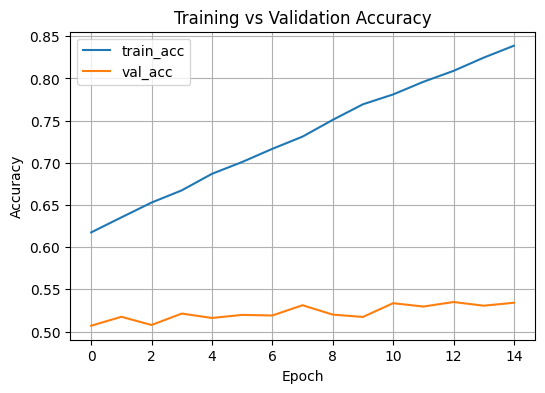

In [28]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#  we can see a sudden shift after 8th epoch, so 8th epoch will be optimal

In [29]:
pred = model.predict(x_test)
pred_cate = np.argmax(pred, axis =1)

901/901 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step


In [30]:

print(classification_report(y_test, pred_cate))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      3205
           1       0.82      0.82      0.82      4938
           2       0.88      0.94      0.91      7164
           3       0.81      0.80      0.81      4103
           4       0.91      0.79      0.84       436
           5       0.88      0.77      0.82      3993
           6       0.81      0.86      0.84      4982

    accuracy                           0.85     28821
   macro avg       0.86      0.84      0.85     28821
weighted avg       0.85      0.85      0.85     28821



In [31]:
print(confusion_matrix(y_test, pred_cate))

[[2788   54  100  135    4   47   77]
 [  29 4028  219  205    4  129  324]
 [  34  126 6728   69    3   51  153]
 [ 140  236  139 3297    6  102  183]
 [   3   30   11   19  343   21    9]
 [  40  229  199  199   12 3085  229]
 [  35  222  236  123    4   76 4286]]


In [ ]:
# Now we are integreating Model with Dynamic Learning Rate to decrease the learning rate at the optimal point

In [35]:

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=8,
    validation_split=0.2,
    callbacks=[reduce_lr]
)

Epoch 1/8
361/361 ━━━━━━━━━━━━━━━━━━━━ 31s 84ms/step - accuracy: 0.9083 - loss: 0.2810 - val_accuracy: 0.5367 - val_loss: 1.8215 - learning_rate: 5.0000e-05
Epoch 2/8
361/361 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9133 - loss: 0.2618 - val_accuracy: 0.5395 - val_loss: 1.8630 - learning_rate: 5.0000e-05
Epoch 3/8
361/361 ━━━━━━━━━━━━━━━━━━━━ 23s 64ms/step - accuracy: 0.9138 - loss: 0.2577 - val_accuracy: 0.5374 - val_loss: 1.9266 - learning_rate: 5.0000e-05
Epoch 4/8
361/361 ━━━━━━━━━━━━━━━━━━━━ 26s 72ms/step - accuracy: 0.9281 - loss: 0.2252 - val_accuracy: 0.5389 - val_loss: 1.9084 - learning_rate: 2.5000e-05
Epoch 5/8
361/361 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.9296 - loss: 0.2211 - val_accuracy: 0.5410 - val_loss: 1.9413 - learning_rate: 2.5000e-05
Epoch 6/8
361/361 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.9316 - loss: 0.2135 - val_accuracy: 0.5382 - val_loss: 1.9380 - learning_rate: 1.2500e-05
Epoch 7/8
361/361 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - acc

## 5. Performance Evaluation
We evaluate the model using a **Classification Report** and a **Confusion Matrix**.
* **Precision/Recall**: Helps us see which emotions the model struggles with (e.g., distinguishing between 'Sad' and 'Neutral').
* **Accuracy Curves**: Visualizing training vs. validation accuracy to check for overfitting.

In [36]:

pred = model.predict(x_test)
pred_cate = np.argmax(pred, axis =1)

901/901 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step


In [37]:
from sklearn.metrics import confusion_matrix,classification_report
print(classification_report(y_test, pred_cate))



              precision    recall  f1-score   support

           0       0.93      0.92      0.92      3205
           1       0.87      0.88      0.87      4938
           2       0.94      0.94      0.94      7164
           3       0.87      0.86      0.87      4103
           4       0.93      0.86      0.90       436
           5       0.88      0.87      0.88      3993
           6       0.88      0.89      0.89      4982

    accuracy                           0.90     28821
   macro avg       0.90      0.89      0.90     28821
weighted avg       0.90      0.90      0.90     28821



In [38]:
print(confusion_matrix(y_test, pred_cate))

[[2935   32   52  109    2   35   40]
 [  23 4331  111  130    2  137  204]
 [  36  122 6758   65    3   67  113]
 [  93  170   67 3548    3  108  114]
 [   1   18    6   12  377   15    7]
 [  34  133   86  116   10 3487  127]
 [  27  182  134   96    7   92 4444]]


In [40]:
model.save("Face.h5") # saving the Model for Opencv

In [2]:


# 1. Define the categories used during training
categories = ['surprise', 'sad', 'happy', 'fear', 'disgust', 'angry', 'neutral']

def face_extractor(img):
    # Detect faces in the frame
    faces = face_cascade.detectMultiScale(img, scaleFactor=1.3, minNeighbors=5)
    
    if len(faces) == 0:
        return None

    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        roi = img[y:y+h, x:x+w]
        return roi

# Load the XML for face detection and your trained facial expression model
face_cascade = cv2.CascadeClassifier(r"C:\Users\Asus\Downloads\haarcascade_frontalface_default.xml")
model = load_model(r"C:\Users\Asus\Downloads\Face.h5")

# Start Video Capture
video_capture = cv2.VideoCapture(0)

while True:
    ret, frame = video_capture.read()
    face = face_extractor(frame)

    if isinstance(face, np.ndarray):
        # Resize to 96x96 as per your training hyperparameter
        face_resized = cv2.resize(face, (96, 96))
        
        # Preprocessing: Convert to float and Normalize
        img_array = face_resized.astype('float16') / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Make Prediction
        predictions = model.predict(img_array)
        max_index = np.argmax(predictions[0]) # Get the index of the highest probability
        emotion_label = categories[max_index] # Map index to emotion name

        # Display the emotion on the frame
        cv2.putText(frame, f"Emotion: {emotion_label}", (75, 75), 
                    cv2.FONT_HERSHEY_COMPLEX, 1, (255, 0, 0), 2)    
    else:
        cv2.putText(frame, "Face not found", (75, 75), 
                    cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2)

    cv2.imshow('Facial Expression Recognition', frame)    

    if cv2.waitKey(20) & 0xff == ord('q'): 
        break

video_capture.release()
cv2.destroyAllWindows()

# use q to quit it

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━